In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [ ]:
df = pd.read_csv("car_prices.csv")
df.head()


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [ ]:
print("Number of records:", len(df))
print("\nData types:")
print(df.dtypes)

Number of records: 352181

Data types:
year              int64
make             object
model            object
trim             object
body             object
transmission     object
vin              object
state            object
condition       float64
odometer        float64
color            object
interior         object
seller           object
mmr             float64
sellingprice    float64
saledate         object
dtype: object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 352181 entries, 0 to 352180
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          352181 non-null  int64  
 1   make          346298 non-null  object 
 2   model         346234 non-null  object 
 3   trim          345969 non-null  object 
 4   body          343425 non-null  object 
 5   transmission  313385 non-null  object 
 6   vin           352181 non-null  object 
 7   state         352180 non-null  object 
 8   condition     340387 non-null  float64
 9   odometer      352095 non-null  float64
 10  color         351675 non-null  object 
 11  interior      351675 non-null  object 
 12  seller        352180 non-null  object 
 13  mmr           352179 non-null  float64
 14  sellingprice  352179 non-null  float64
 15  saledate      352179 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 43.0+ MB


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 352181
Columns: 16


In [ ]:
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Shape of dataset: (352181, 16)

Column names:
['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state', 'condition', 'odometer', 'color', 'interior', 'seller', 'mmr', 'sellingprice', 'saledate']


In [ ]:
missing_values = df.isnull().sum()

print(missing_values)

year                0
make             5883
model            5947
trim             6212
body             8756
transmission    38796
vin                 0
state               1
condition       11794
odometer           86
color             506
interior          506
seller              1
mmr                 2
sellingprice        2
saledate            2
dtype: int64


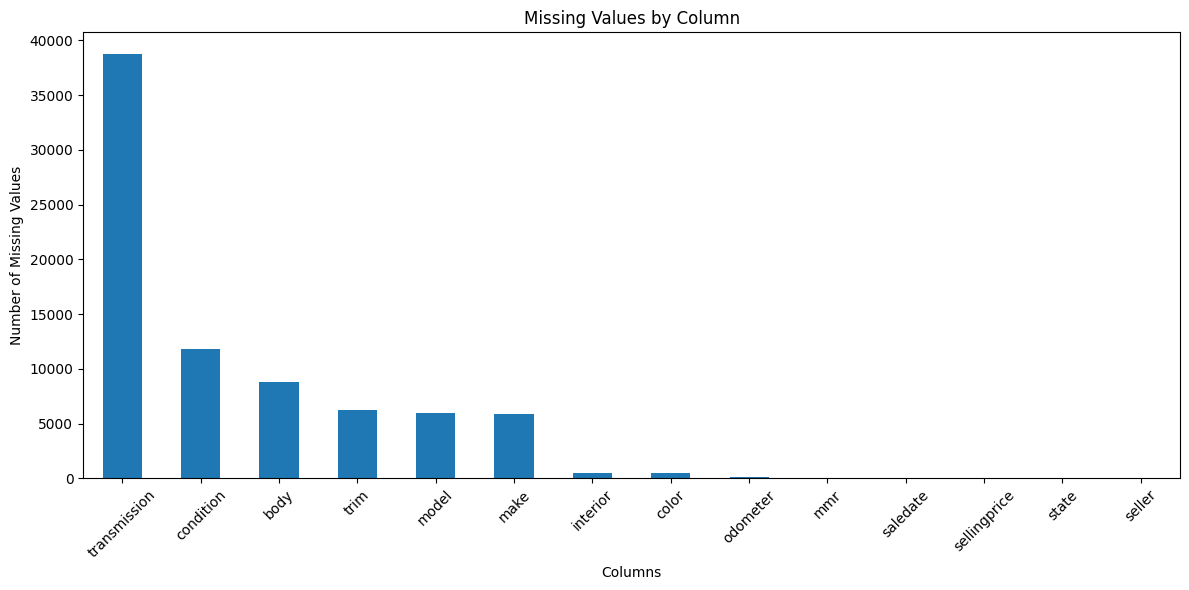

In [ ]:
plt.figure(figsize=(12, 6))

missing_values[missing_values > 0].sort_values(ascending=False).plot(
    kind='bar'
)

plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [ ]:
if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed.")
else:
    print("No duplicate records found.")

print("Current dataset shape:", df.shape)

No duplicate records found.
Current dataset shape: (352181, 16)


In [ ]:
df.columns.tolist()

['year',
 'make',
 'model',
 'trim',
 'body',
 'transmission',
 'vin',
 'state',
 'condition',
 'odometer',
 'color',
 'interior',
 'seller',
 'mmr',
 'sellingprice',
 'saledate']

In [ ]:
print("Average Selling Price:", df["sellingprice"].mean())
print("Minimum Selling Price:", df["sellingprice"].min())
print("Maximum Selling Price:", df["sellingprice"].max())

Average Selling Price: 13194.709377901578
Minimum Selling Price: 1.0
Maximum Selling Price: 230000.0


In [ ]:
unique_colors = df["color"].dropna().unique()

print("Unique car colors:")
print(unique_colors)

print("\nNumber of unique colors:", len(unique_colors))

Unique car colors:
['white' 'gray' 'black' 'red' 'silver' 'blue' 'brown' 'beige' 'purple'
 'burgundy' '—' 'gold' 'yellow' 'green' 'charcoal' 'orange' 'off-white'
 'turquoise' 'pink' 'lime']

Number of unique colors: 20


In [ ]:
unique_brands = df["make"].dropna().nunique()
unique_models = df["model"].dropna().nunique()

print("Number of unique car brands:", unique_brands)
print("Number of unique car models:", unique_models)

Number of unique car brands: 95
Number of unique car models: 940


In [ ]:
high_price_cars = df[df["sellingprice"] > 165000]

print("Number of cars with selling price greater than $165,000:",
      len(high_price_cars))

high_price_cars

Number of cars with selling price greater than $165,000: 2


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
125095,2012,Rolls-Royce,Ghost,Base,Sedan,automatic,sca664s58cux50727,fl,45.0,14316.0,black,beige,braman motorcars,154000.0,169500.0,Wed Jan 14 2015 01:40:00 GMT-0800 (PST)
344905,2014,Ford,Escape,Titanium,SUV,automatic,1fmcu9j98eua23833,mo,43.0,27802.0,green,tan,ford-lincoln dealer program,22800.0,230000.0,Wed Feb 25 2015 02:00:00 GMT-0800 (PST)


In [ ]:
top_5_models = df["model"].value_counts().head(5)

print("Top 5 most frequently sold car models:")
print(top_5_models)

Top 5 most frequently sold car models:
model
Altima    12438
F-150      8968
Fusion     8030
Escape     7522
Camry      7502
Name: count, dtype: int64


In [ ]:
avg_price_by_make = (
    df.groupby("make")["sellingprice"]
    .mean()
    .sort_values(ascending=False)
)

print("Average selling price by brand:")
print(avg_price_by_make)

Average selling price by brand:
make
Rolls-Royce    152828.571429
Ferrari        135428.571429
Lamborghini    112250.000000
Tesla           74500.000000
Bentley         71052.343750
                   ...      
Geo               553.571429
dodge tk          550.000000
dot               500.000000
ford truck        483.333333
Daewoo            300.000000
Name: sellingprice, Length: 95, dtype: float64


In [ ]:
min_price_by_interior = (
    df.groupby("interior")["sellingprice"]
    .min()
    .sort_values()
)

print("Minimum selling price by interior:")
print(min_price_by_interior)

Minimum selling price by interior:
interior
black           1.0
gray            1.0
beige         100.0
tan           100.0
silver        150.0
blue          150.0
—             150.0
burgundy      175.0
red           200.0
purple        200.0
brown         200.0
green         250.0
gold          250.0
white         350.0
off-white     900.0
orange       1200.0
yellow       3700.0
Name: sellingprice, dtype: float64


In [ ]:
highest_odometer_by_year = (
    df.groupby("year")["odometer"]
    .max()
    .sort_values(ascending=False)
)

print("Highest odometer reading per year:")
print(highest_odometer_by_year)

Highest odometer reading per year:
year
1999    999999.0
2008    999999.0
1998    999999.0
2007    999999.0
2014    999999.0
2011    999999.0
2010    999999.0
2013    999999.0
2012    999999.0
2004    999999.0
2009    999999.0
2003    999999.0
2006    999999.0
2001    999999.0
2005    999999.0
1996    959276.0
2002    694978.0
2000    462579.0
1997    423691.0
1995    396793.0
1992    379307.0
1993    378670.0
1994    347605.0
1991    274149.0
1990    249117.0
1988    241751.0
1989    218052.0
1987    195154.0
1986    192934.0
1984    170799.0
1985    121644.0
2015    100454.0
1982     85738.0
Name: odometer, dtype: float64


In [ ]:
df["car_age"] = 2025 - df["year"]

print("Car age column created successfully.")
df[["year", "car_age"]].head()

Car age column created successfully.


,year,car_age
0,2015,10
1,2015,10
2,2014,11
3,2015,10
4,2014,11


In [ ]:
condition_odometer_cars = df[
    (df["condition"] >= 48) &
    (df["odometer"] > 90000)
]

print(
    "Number of cars with condition >= 48 and odometer > 90,000:",
    len(condition_odometer_cars)
)

Number of cars with condition >= 48 and odometer > 90,000: 493


In [ ]:
newer_cars = df[df["year"] > 2013]

avg_price_by_state = (
    newer_cars.groupby("state")["sellingprice"]
    .mean()
    .sort_values(ascending=False)
)

print("Average selling price by state for cars newer than 2013:")
print(avg_price_by_state)

Average selling price by state for cars newer than 2013:
state
ms    31700.000000
oh    28670.341170
ab    25724.705882
nj    24111.693385
qc    22746.689895
on    22528.388090
tn    21983.937975
ne    21294.317757
pa    21190.464427
co    21016.055456
ny    20808.171206
ca    20561.180960
mi    20388.591133
wa    20291.412946
nv    20036.315594
tx    19755.736693
ga    19623.742137
mn    19582.289562
ma    19551.666667
fl    19493.294151
az    19406.690141
mo    19341.338034
il    19336.002709
va    19270.555033
wi    19216.282081
la    18675.653846
md    18509.971098
hi    17993.478261
ut    17806.111111
al    17800.000000
sc    17133.771765
nc    17080.008881
or    15946.726190
pr    15860.000000
in    15563.051471
nm     7000.000000
Name: sellingprice, dtype: float64


In [ ]:
print("Top 10 states by average selling price:")
print(avg_price_by_state.head(10))

Top 10 states by average selling price:
state
ms    31700.000000
oh    28670.341170
ab    25724.705882
nj    24111.693385
qc    22746.689895
on    22528.388090
tn    21983.937975
ne    21294.317757
pa    21190.464427
co    21016.055456
Name: sellingprice, dtype: float64


In [ ]:
condition_threshold = df["condition"].quantile(0.80)

print("80th percentile condition score:", condition_threshold)

80th percentile condition score: 43.0


In [ ]:
excellent_condition_cars = df[
    df["condition"] >= condition_threshold
]

print("Number of excellent-condition cars:",
      len(excellent_condition_cars))

Number of excellent-condition cars: 69995


In [ ]:
value_for_money = (
    excellent_condition_cars
    .groupby("make")["sellingprice"]
    .mean()
    .sort_values()
)

print("Makes with lowest average selling price among excellent-condition cars:")
print(value_for_money.head(10))

Makes with lowest average selling price among excellent-condition cars:
make
Oldsmobile    2566.666667
honda         4233.333333
Saturn        5601.265823
subaru        6200.000000
chrysler      6225.000000
Pontiac       7000.531915
mazda         7275.000000
smart         7650.000000
Saab          7871.428571
nissan        8000.000000
Name: sellingprice, dtype: float64


In [ ]:
# Task 3.1: Correlation of numerical columns

numerical_columns = df.select_dtypes(include=np.number)

correlation_matrix = numerical_columns.corr()

print("Correlation matrix:")
display(correlation_matrix)

Correlation matrix:


,year,condition,odometer,mmr,sellingprice,car_age
year,1.000000,0.346270,-0.773175,0.617911,0.607096,-1.000000
condition,0.346270,1.000000,-0.318325,0.290323,0.332752,-0.346270
odometer,-0.773175,-0.318325,1.000000,-0.605499,-0.598146,0.773175
mmr,0.617911,0.290323,-0.605499,1.000000,0.983195,-0.617911
sellingprice,0.607096,0.332752,-0.598146,0.983195,1.000000,-0.607096
car_age,-1.000000,-0.346270,0.773175,-0.617911,-0.607096,1.000000


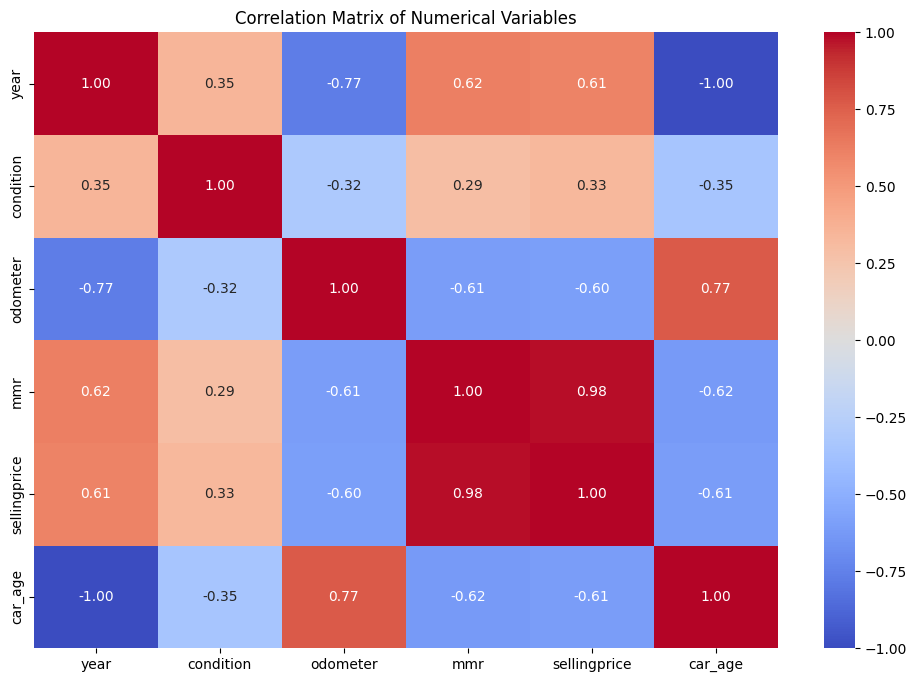

In [ ]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Variables")
plt.show()

In [ ]:
avg_price_by_year = (
    df.groupby("year")["sellingprice"]
    .mean()
    .sort_index()
)

print("Average selling price by year:")
display(avg_price_by_year)

Average selling price by year:


,sellingprice
year,
1982,5000.000000
1984,2160.000000
1985,3666.666667
1986,2668.750000
1987,1866.666667
1988,2775.000000
1989,1603.125000
1990,1162.878788
1991,866.666667


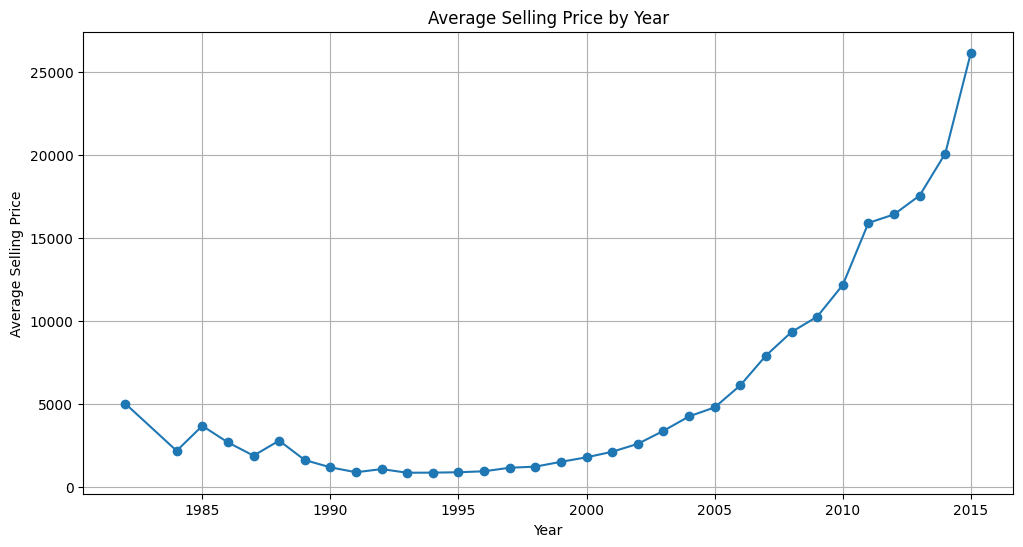

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    avg_price_by_year.index,
    avg_price_by_year.values,
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Average Selling Price")
plt.title("Average Selling Price by Year")
plt.grid(True)

plt.show()

The average selling price generally increases with the model year. Older vehicles have lower average selling prices, while newer vehicles tend to have higher average prices. Although some fluctuations are observed for older model years, there is a clear upward trend, particularly after 2000. The average selling price increases substantially from 2005 onward and reaches the highest value in 2015.


In [ ]:
avg_price_by_odometer = (
    df.groupby("odometer")["sellingprice"]
    .mean()
    .sort_index()
)

print("Average selling price by odometer:")
display(avg_price_by_odometer.head(20))

Average selling price by odometer:


,sellingprice
odometer,
1.0,2376.858373
2.0,14787.500000
3.0,23737.500000
4.0,16156.250000
5.0,20460.000000
6.0,22061.111111
7.0,24475.000000
8.0,21266.666667
9.0,20362.500000


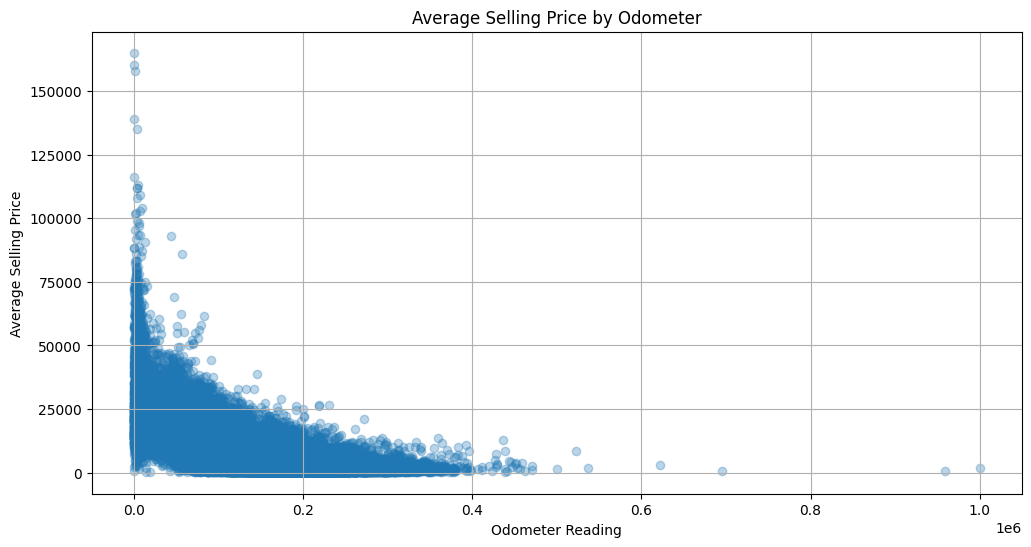

In [ ]:
plt.figure(figsize=(12, 6))

plt.scatter(
    avg_price_by_odometer.index,
    avg_price_by_odometer.values,
    alpha=0.3
)

plt.xlabel("Odometer Reading")
plt.ylabel("Average Selling Price")
plt.title("Average Selling Price by Odometer")
plt.grid(True)

plt.show()

In [ ]:
state_sales = df["state"].value_counts()

print(state_sales)

state
ca    49569
fl    49160
pa    31288
tx    29066
ga    21734
nj    17492
nc    14925
il    14765
tn    14577
oh    13630
mo    10882
mi     9180
va     8553
nv     8120
md     7595
wi     6698
mn     6011
az     5321
wa     4697
co     4142
ny     3771
ma     3713
in     2748
ne     2551
sc     2416
on     1954
pr     1732
la     1652
ut     1235
or      862
hi      822
qc      753
ab      487
ok       38
al       20
nm       11
ms       10
Name: count, dtype: int64


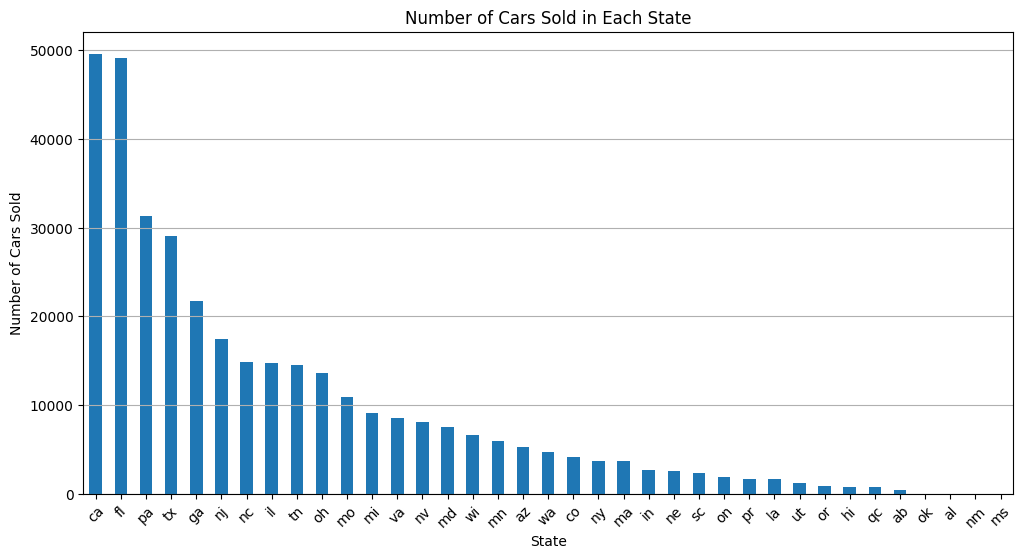

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

state_sales.plot(kind="bar")

plt.xlabel("State")
plt.ylabel("Number of Cars Sold")
plt.title("Number of Cars Sold in Each State")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

In [ ]:
top_3_states = state_sales.head(3)

print("Top 3 highest car selling states:")
print(top_3_states)

Top 3 highest car selling states:
state
ca    49569
fl    49160
pa    31288
Name: count, dtype: int64


In [ ]:
print(df["condition"].describe())

count    340387.000000
mean         30.378222
std          13.642833
min           1.000000
25%          23.000000
50%          34.000000
75%          41.000000
max          49.000000
Name: condition, dtype: float64


In [ ]:
bins = range(0, 51, 5)

df["condition_range_5"] = pd.cut(
    df["condition"],
    bins=bins,
    right=False
)

In [ ]:
avg_price_condition = df.groupby(
    "condition_range_5",
    observed=False
)["sellingprice"].mean()

print(avg_price_condition)

condition_range_5
[0, 5)      10259.267113
[5, 10)     23777.986697
[10, 15)     3888.247232
[15, 20)     4987.390492
[20, 25)     7650.599007
[25, 30)     9579.236601
[30, 35)    11982.290449
[35, 40)    14436.588177
[40, 45)    17967.271123
[45, 50)    20789.611906
Name: sellingprice, dtype: float64


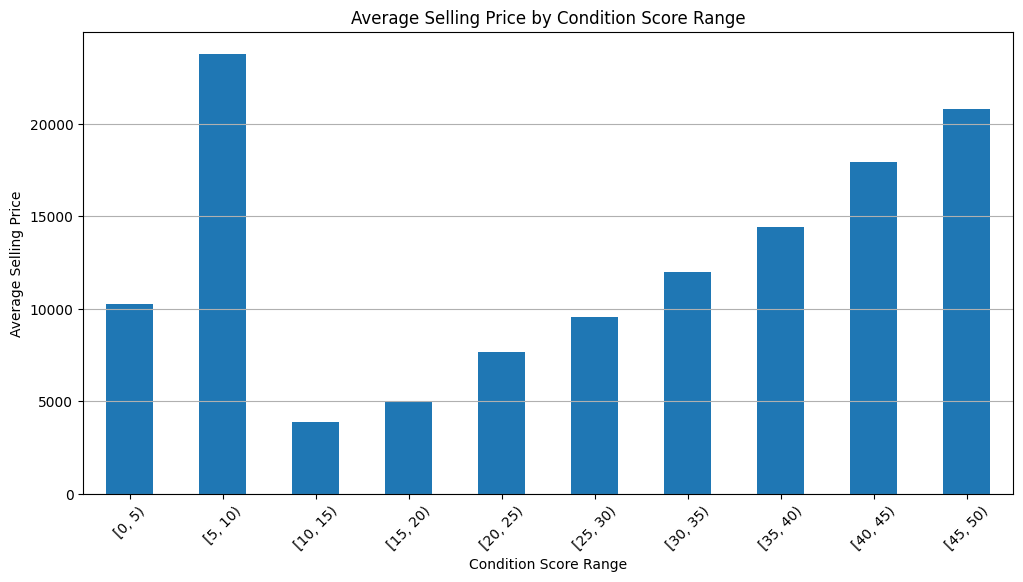

In [ ]:
plt.figure(figsize=(12, 6))

avg_price_condition.plot(kind="bar")

plt.xlabel("Condition Score Range")
plt.ylabel("Average Selling Price")
plt.title("Average Selling Price by Condition Score Range")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

In [ ]:
bins = range(0, 101, 10)

df["condition_range_10"] = pd.cut(
    df["condition"],
    bins=bins,
    right=False
)

In [ ]:
cars_by_condition = df["condition_range_10"].value_counts().sort_index()

print(cars_by_condition)

condition_range_10
[0, 10)      46424
[10, 20)     27343
[20, 30)     69488
[30, 40)     98234
[40, 50)     98898
[50, 60)         0
[60, 70)         0
[70, 80)         0
[80, 90)         0
[90, 100)        0
Name: count, dtype: int64


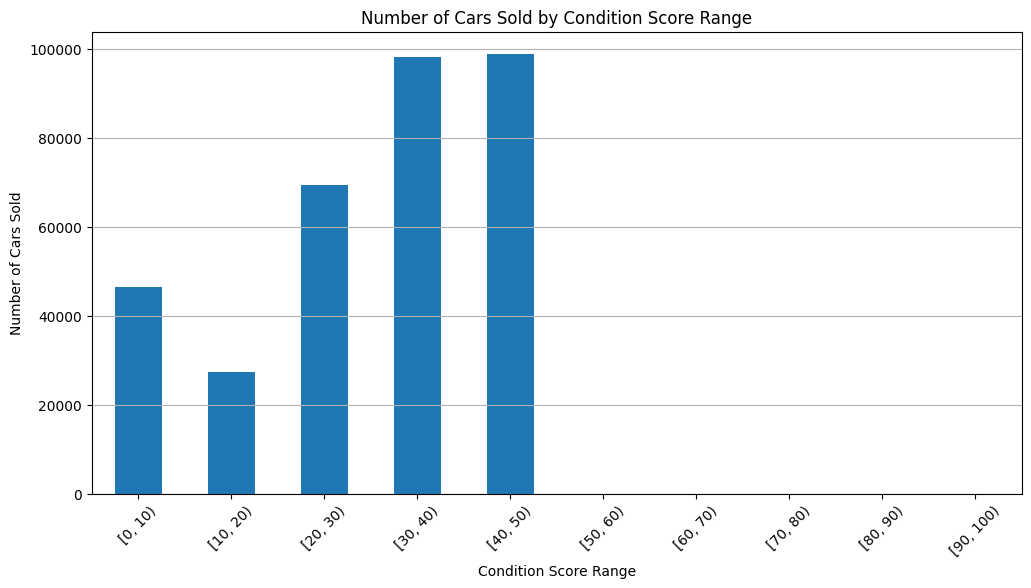

In [ ]:
plt.figure(figsize=(12, 6))

cars_by_condition.plot(kind="bar")

plt.xlabel("Condition Score Range")
plt.ylabel("Number of Cars Sold")
plt.title("Number of Cars Sold by Condition Score Range")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

<Figure size 1400x700 with 0 Axes>

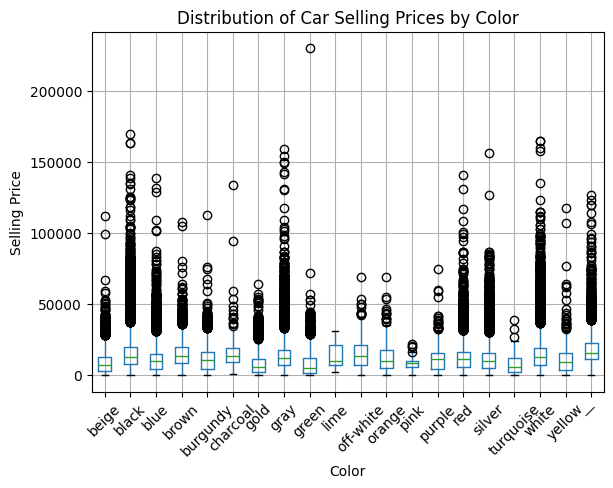

In [ ]:
plt.figure(figsize=(14, 7))

df.boxplot(
    column="sellingprice",
    by="color",
    rot=45
)

plt.xlabel("Color")
plt.ylabel("Selling Price")
plt.title("Distribution of Car Selling Prices by Color")
plt.suptitle("")

plt.show()

In [ ]:
Q1 = df["sellingprice"].quantile(0.25)
Q3 = df["sellingprice"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Lower bound: -10700.0
Upper bound: 34900.0


In [ ]:
df_no_outliers = df[
    (df["sellingprice"] >= lower_bound) &
    (df["sellingprice"] <= upper_bound)
]

<Figure size 1400x700 with 0 Axes>

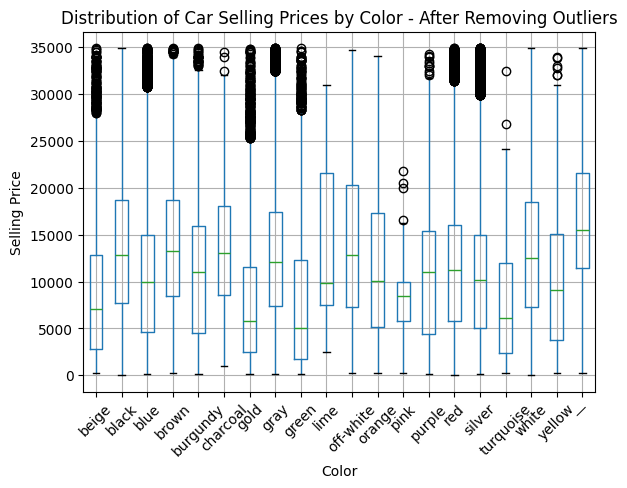

In [ ]:
plt.figure(figsize=(14, 7))

df_no_outliers.boxplot(
    column="sellingprice",
    by="color",
    rot=45
)

plt.xlabel("Color")
plt.ylabel("Selling Price")
plt.title("Distribution of Car Selling Prices by Color - After Removing Outliers")
plt.suptitle("")

plt.show()

In [ ]:
state_sales = df["state"].value_counts()

print(state_sales)

state
ca    49569
fl    49160
pa    31288
tx    29066
ga    21734
nj    17492
nc    14925
il    14765
tn    14577
oh    13630
mo    10882
mi     9180
va     8553
nv     8120
md     7595
wi     6698
mn     6011
az     5321
wa     4697
co     4142
ny     3771
ma     3713
in     2748
ne     2551
sc     2416
on     1954
pr     1732
la     1652
ut     1235
or      862
hi      822
qc      753
ab      487
ok       38
al       20
nm       11
ms       10
Name: count, dtype: int64


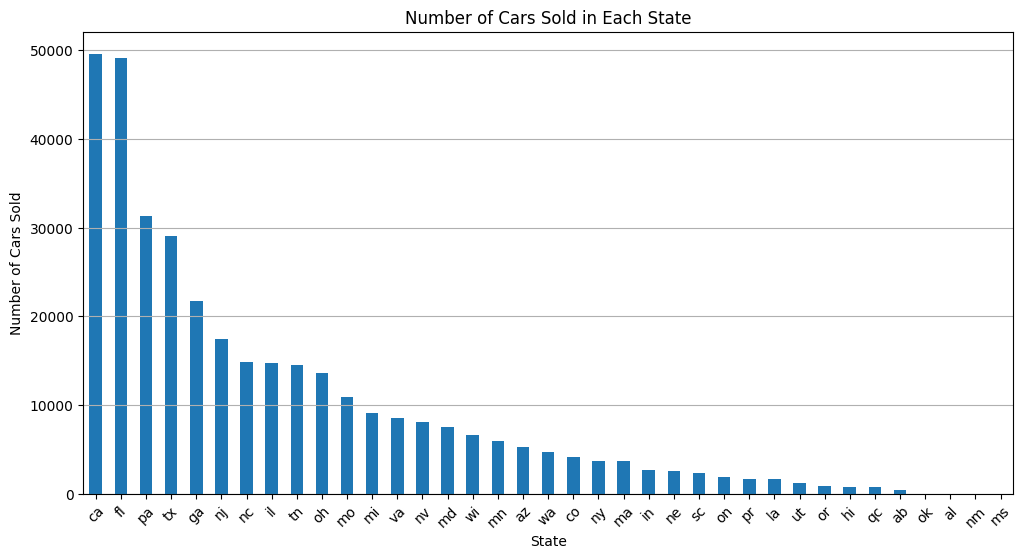

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
state_sales.plot(kind="bar")

plt.xlabel("State")
plt.ylabel("Number of Cars Sold")
plt.title("Number of Cars Sold in Each State")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

In [ ]:
top_3_states = state_sales.head(3)

print("Top 3 highest car selling states:")
for state, count in top_3_states.items():
    print(state, ":", count)

Top 3 highest car selling states:
ca : 49569
fl : 49160
pa : 31288


California (CA) has the highest number of cars sold with 49,569 sales, followed closely by Florida (FL) with 49,160 sales. Pennsylvania (PA) ranks third with 31,288 cars sold. Therefore, CA, FL, and PA are the top three car-selling states in the dataset.
